# **Taming XGBoost: How Regularisation and Tree Complexity Control Overfitting**

**Machine Learning Tutorial (REF / Resit) — Module 7PAM2021**

GitHub Link : https://github.com/mani04180/xgboost-regularisation-tutorial

---

**What you will learn**

XGBoost is powerful, but with default settings it will happily memorise your training
data and generalise poorly. This tutorial teaches **one focused idea**: how a small set
of hyperparameters — **tree depth, learning rate, and the regularisation terms** —
move XGBoost along the **bias–variance trade-off**, and how to read the
**train-vs-validation gap** to diagnose overfitting.

**Dataset:** UCI *Concrete Compressive Strength* (1,030 samples, 8 numeric features,
regression target = compressive strength in MPa). It is small enough that deep trees
overfit visibly, which makes the lesson easy to see.

**Why this dataset:** it is clean, fully numeric, has no missing values, and is *not*
one of the over-used tutorial datasets (Titanic / Boston / California housing).


## **1. Setup and reproducibility**

We import our libraries, fix a random seed so every run is identical, and define a
**colour-blind-safe palette** (Okabe–Ito) plus distinct line styles so all figures
remain readable in greyscale and for colour-blind readers (accessibility).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

# --- Reproducibility ---
SEED = 42
np.random.seed(SEED)

# --- Accessible styling (Okabe-Ito, colour-blind safe) ---
OKABE = ["#0072B2", "#E69F00", "#009E73", "#D55E00",
         "#CC79A7", "#56B4E9", "#F0E442", "#000000"]
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
    "axes.prop_cycle": plt.cycler(color=OKABE),
})

def rmse(y_true, y_pred):
    "Root mean squared error in the target's own units (MPa)."
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("xgboost", xgb.__version__)


xgboost 3.2.0


## **2. Load the data**

We read the dataset from the local `concrete.csv` that ships with the repository, so the
notebook is **fully reproducible offline**. If that file is missing, we fall back to the
public UCI URL.


In [2]:
COLS = ["cement", "blast_furnace_slag", "fly_ash", "water", "superplasticizer",
        "coarse_aggregate", "fine_aggregate", "age", "compressive_strength"]
try:
    df = pd.read_csv("concrete.csv")
except FileNotFoundError:
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
           "concrete/compressive/Concrete_Data.xls")
    df = pd.read_excel(url)
    df.columns = COLS
    df.to_csv("concrete.csv", index=False)

print("Shape:", df.shape)
df.head()


Shape: (1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


## **3. A quick look at the data**

Before modelling we check the **target distribution** and the **feature correlations**.
The target ranges roughly from 2 to 83 MPa, so an RMSE of, say, 5 MPa is meaningful in
context.


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength
count,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0
mean,281.2,73.9,54.2,181.6,6.2,972.9,773.6,45.7,35.8
std,104.5,86.3,64.0,21.4,6.0,77.8,80.2,63.2,16.7
min,102.0,0.0,0.0,121.8,0.0,801.0,594.0,1.0,2.3
25%,192.4,0.0,0.0,164.9,0.0,932.0,731.0,7.0,23.7
50%,272.9,22.0,0.0,185.0,6.4,968.0,779.5,28.0,34.4
75%,350.0,143.0,118.3,192.0,10.2,1029.4,824.0,56.0,46.1
max,540.0,359.4,200.1,247.0,32.2,1145.0,992.6,365.0,82.6


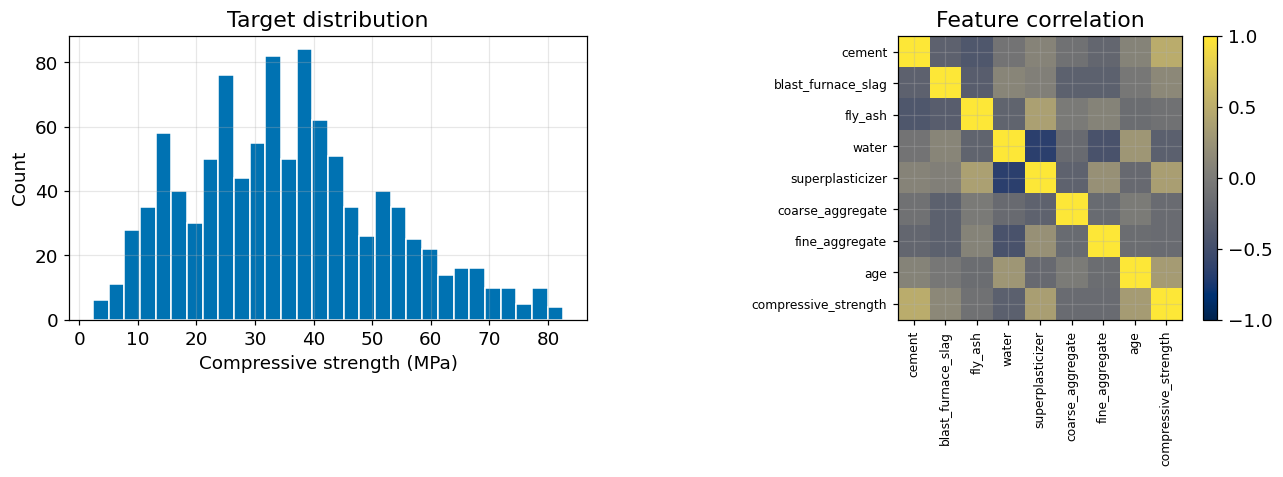

In [ ]:
display(df.describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].hist(df["compressive_strength"], bins=30, color=OKABE[0], edgecolor="white")
ax[0].set_title("Target distribution")
ax[0].set_xlabel("Compressive strength (MPa)")
ax[0].set_ylabel("Count")

corr = df.corr()
im = ax[1].imshow(corr, cmap="cividis", vmin=-1, vmax=1)
ax[1].set_xticks(range(len(COLS)))
ax[1].set_yticks(range(len(COLS)))
ax[1].set_xticklabels(COLS, rotation=90, fontsize=8)
ax[1].set_yticklabels(COLS, fontsize=8)
ax[1].set_title("Feature correlation")
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## **4. Train / validation / test split**

We hold out a **test set** we never touch during tuning, and carve a **validation set**
out of the training data. The validation set is what reveals overfitting: a model that
is memorising will keep improving on *train* while *validation* error stalls or rises.


In [4]:
X = df.drop(columns="compressive_strength")
y = df["compressive_strength"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=SEED)  # 0.25 * 0.8 = 0.2

print(f"train={X_tr.shape[0]}  val={X_val.shape[0]}  test={X_test.shape[0]}")


train=618  val=206  test=206


## **5. Watching XGBoost overfit**

Let's deliberately build an **over-powered model**: deep trees, no regularisation, many
rounds. Watch the **gap** between train RMSE (near zero) and validation RMSE — that gap
*is* overfitting.


In [5]:
overfit = xgb.XGBRegressor(
    n_estimators=400, max_depth=12, learning_rate=0.3,
    reg_lambda=0, reg_alpha=0, gamma=0, min_child_weight=1,
    subsample=1.0, colsample_bytree=1.0,
    random_state=SEED, n_jobs=-1)
overfit.fit(X_tr, y_tr)

print(f"Train RMSE: {rmse(y_tr,  overfit.predict(X_tr)):.2f} MPa")
print(f"Val   RMSE: {rmse(y_val, overfit.predict(X_val)):.2f} MPa")
print(f"Gap (val - train): "
      f"{rmse(y_val, overfit.predict(X_val)) - rmse(y_tr, overfit.predict(X_tr)):.2f} MPa")


Train RMSE: 0.96 MPa
Val   RMSE: 6.20 MPa
Gap (val - train): 5.24 MPa


## **6. Lever 1 — tree depth (`max_depth`)**

`max_depth` controls how complex each tree can be. **Shallow trees underfit** (high bias);
**deep trees overfit** (high variance). We sweep depth and plot train vs validation RMSE —
the classic **bias–variance U-curve** appears on the validation line.


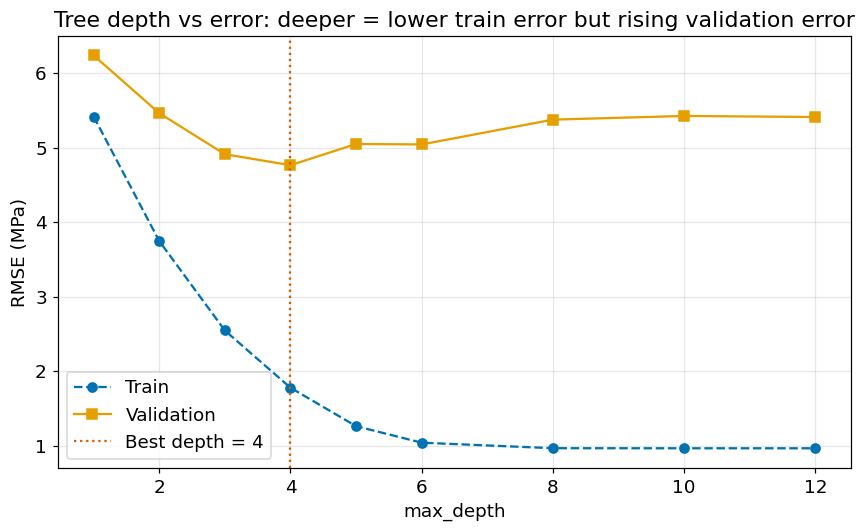

Best validation depth: 4


In [ ]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 12]
tr_rmse, val_rmse = [], []
for d in depths:
    m = xgb.XGBRegressor(n_estimators=300, max_depth=d, learning_rate=0.1,
                         random_state=SEED, n_jobs=-1)
    m.fit(X_tr, y_tr)
    tr_rmse.append(rmse(y_tr,  m.predict(X_tr)))
    val_rmse.append(rmse(y_val, m.predict(X_val)))

plt.figure()
plt.plot(depths, tr_rmse,  marker="o", linestyle="--", label="Train")
plt.plot(depths, val_rmse, marker="s", linestyle="-",  label="Validation")
best_d = depths[int(np.argmin(val_rmse))]
plt.axvline(best_d, color=OKABE[3], linestyle=":", label=f"Best depth = {best_d}")
plt.xlabel("max_depth"); plt.ylabel("RMSE (MPa)")
plt.title("Tree depth vs error: deeper = lower train error but rising validation error")
plt.legend(); plt.tight_layout()
plt.show()
print("Best validation depth:", best_d)


## **7. Lever 2 — learning rate (`learning_rate` / eta)**

The learning rate shrinks each tree's contribution. **Lower rates generalise better** but
need **more trees**. We sweep the rate at a fixed number of rounds to show the trade-off.


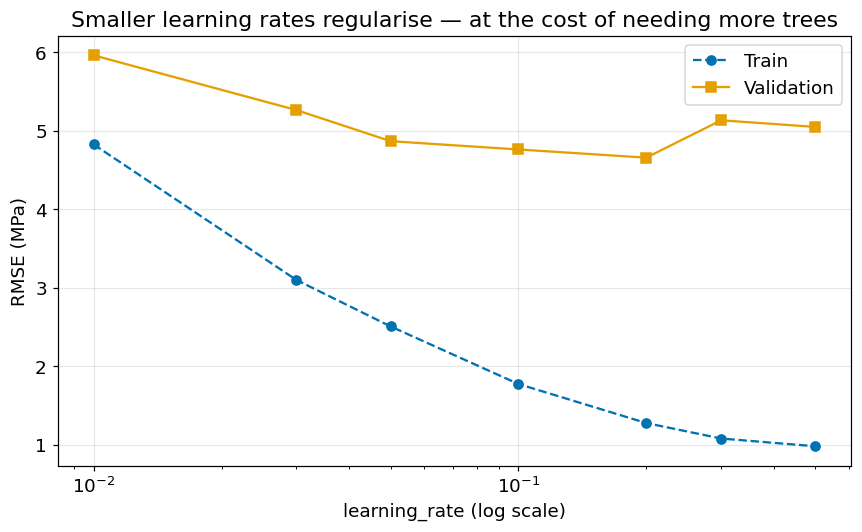

In [ ]:
rates = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]
tr_r, val_r = [], []
for lr in rates:
    m = xgb.XGBRegressor(n_estimators=300, max_depth=best_d, learning_rate=lr,
                         random_state=SEED, n_jobs=-1)
    m.fit(X_tr, y_tr)
    tr_r.append(rmse(y_tr,  m.predict(X_tr)))
    val_r.append(rmse(y_val, m.predict(X_val)))

plt.figure()
plt.plot(rates, tr_r,  marker="o", linestyle="--", label="Train")
plt.plot(rates, val_r, marker="s", linestyle="-",  label="Validation")
plt.xscale("log")
plt.xlabel("learning_rate (log scale)"); plt.ylabel("RMSE (MPa)")
plt.title("Smaller learning rates regularise — at the cost of needing more trees")
plt.legend(); plt.tight_layout()
plt.show()


## **8. Lever 3 — explicit regularisation (`reg_lambda`)**

XGBoost adds an **L2 penalty** (`reg_lambda`) on leaf weights, plus `gamma` (minimum gain
to split) and `min_child_weight`. Increasing `reg_lambda` **shrinks leaf values toward
zero**, closing the train–validation gap. We sweep it on the deep, otherwise-overfit model.


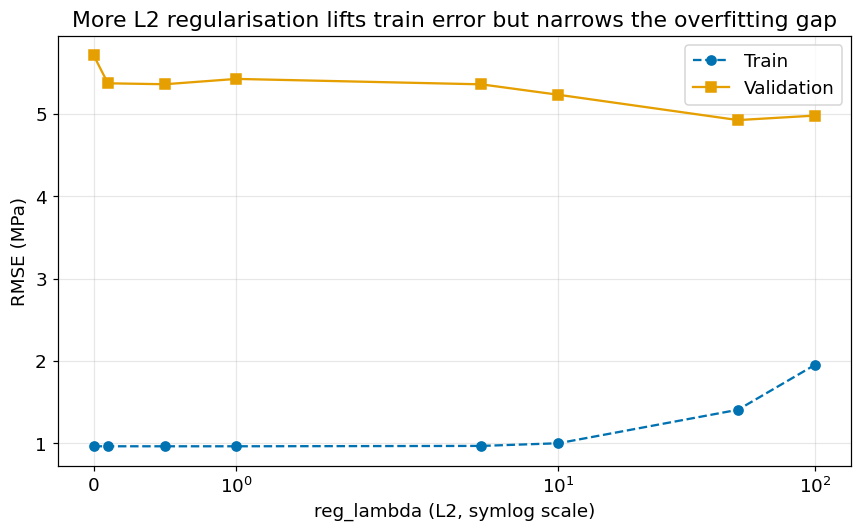

In [ ]:
lambdas = [0, 0.1, 0.5, 1, 5, 10, 50, 100]
tr_l, val_l = [], []
for lam in lambdas:
    m = xgb.XGBRegressor(n_estimators=300, max_depth=10, learning_rate=0.1,
                         reg_lambda=lam, random_state=SEED, n_jobs=-1)
    m.fit(X_tr, y_tr)
    tr_l.append(rmse(y_tr,  m.predict(X_tr)))
    val_l.append(rmse(y_val, m.predict(X_val)))

plt.figure()
plt.plot(lambdas, tr_l,  marker="o", linestyle="--", label="Train")
plt.plot(lambdas, val_l, marker="s", linestyle="-",  label="Validation")
plt.xscale("symlog")
plt.xlabel("reg_lambda (L2, symlog scale)"); plt.ylabel("RMSE (MPa)")
plt.title("More L2 regularisation lifts train error but narrows the overfitting gap")
plt.legend(); plt.tight_layout()
plt.show()


## **9. Putting it together — early stopping**

Rather than guess the number of trees, we let **early stopping** find it: keep adding
trees while validation RMSE improves, and stop when it stalls. The **learning curve**
below shows training error falling steadily while validation error flattens — the point
where they diverge is where overfitting would begin.


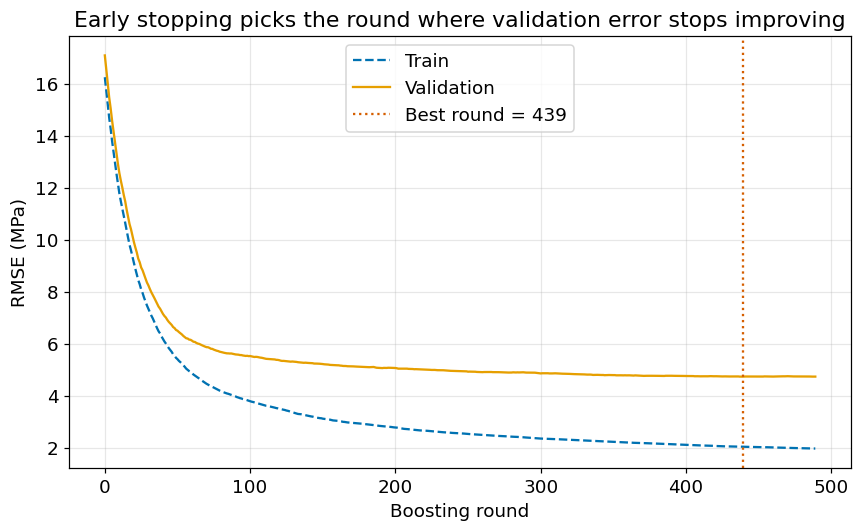

Stopped at round: 439


In [ ]:
tuned = xgb.XGBRegressor(
    n_estimators=2000, max_depth=best_d, learning_rate=0.05,
    reg_lambda=1.0, min_child_weight=3, gamma=0.0,
    subsample=0.8, colsample_bytree=0.8,
    early_stopping_rounds=50, eval_metric="rmse",
    random_state=SEED, n_jobs=-1)
tuned.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False)

res = tuned.evals_result()
train_curve = res["validation_0"]["rmse"]
val_curve   = res["validation_1"]["rmse"]
best_iter = tuned.best_iteration

plt.figure()
plt.plot(train_curve, linestyle="--", label="Train")
plt.plot(val_curve,   linestyle="-",  label="Validation")
plt.axvline(best_iter, color=OKABE[3], linestyle=":",
            label=f"Best round = {best_iter}")
plt.xlabel("Boosting round"); plt.ylabel("RMSE (MPa)")
plt.title("Early stopping picks the round where validation error stops improving")
plt.legend(); plt.tight_layout()
plt.show()
print("Stopped at round:", best_iter)


## **10. The payoff — overfit vs tuned on the untouched test set**

Now we judge both models on the **held-out test set** that neither model has seen. The
regularised model gives a **smaller train–test gap** and **better test RMSE / R²** — it
generalises.


,Model,Train RMSE,Test RMSE,Train-Test gap,Test R2
0,"Overfit (deep, no reg.)",3.21,6.47,3.26,0.838
1,Tuned (regularised + early stop),2.96,4.66,1.71,0.916


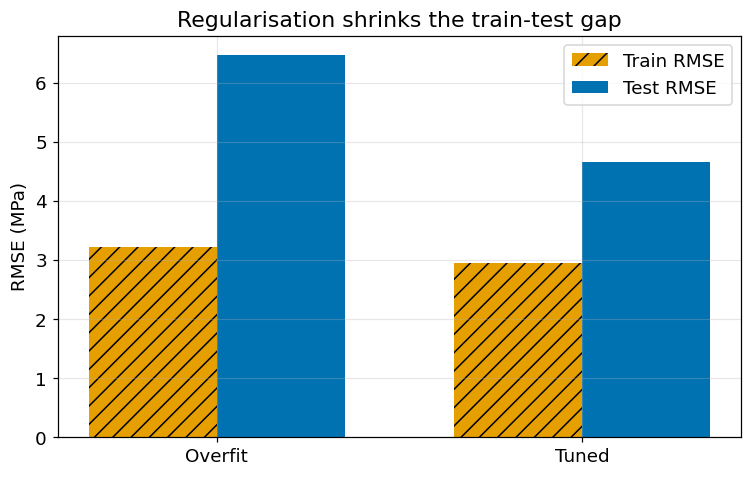

In [ ]:
def report(model):
    return (rmse(y_train, model.predict(X_train)),
            rmse(y_test,  model.predict(X_test)),
            r2_score(y_test, model.predict(X_test)))

tr1, te1, r1 = report(overfit)
tr2, te2, r2 = report(tuned)

summary = pd.DataFrame({
    "Model": ["Overfit (deep, no reg.)", "Tuned (regularised + early stop)"],
    "Train RMSE": [round(tr1, 2), round(tr2, 2)],
    "Test RMSE":  [round(te1, 2), round(te2, 2)],
    "Train-Test gap": [round(te1 - tr1, 2), round(te2 - tr2, 2)],
    "Test R2": [round(r1, 3), round(r2, 3)],
})
display(summary)

plt.figure(figsize=(7, 4.5))
x = np.arange(2); w = 0.35
plt.bar(x - w/2, [tr1, tr2], w, label="Train RMSE", color=OKABE[1], hatch="//")
plt.bar(x + w/2, [te1, te2], w, label="Test RMSE",  color=OKABE[0])
plt.xticks(x, ["Overfit", "Tuned"]); plt.ylabel("RMSE (MPa)")
plt.title("Regularisation shrinks the train-test gap")
plt.legend(); plt.tight_layout()
plt.show()


## **11. Bonus — what drives the prediction**

A quick **feature-importance** view (by gain) shows the tuned model relies most on
**age**, **cement**, and **water** — chemically sensible drivers of concrete strength.
Treat gain importance as a rough guide, not a causal claim.


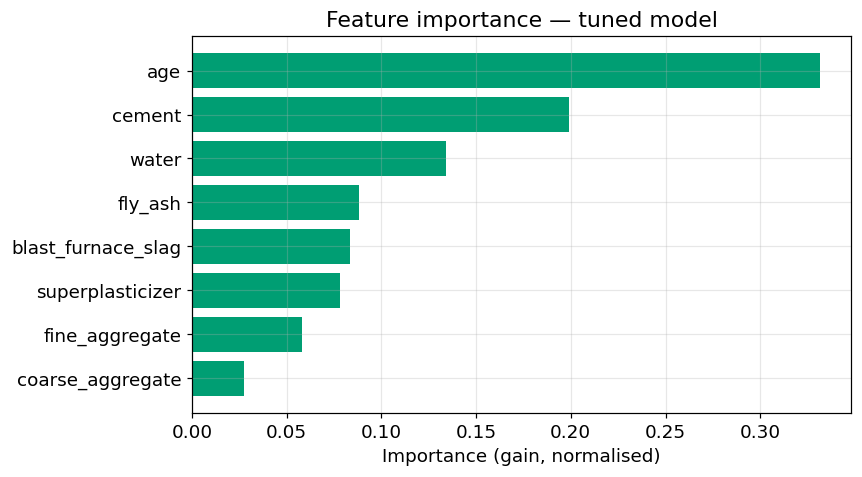

In [ ]:
imp = pd.Series(tuned.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 4.5))
plt.barh(imp.index, imp.values, color=OKABE[2])
plt.xlabel("Importance (gain, normalised)")
plt.title("Feature importance — tuned model")
plt.tight_layout()
plt.show()


## **12. Key takeaways**

- **Overfitting is visible as a train–validation gap.** Always track both, never train alone.
- **`max_depth`** is the strongest complexity dial: shallow underfits, deep overfits — there is a sweet spot.
- **`learning_rate`** trades generalisation for training time: smaller is safer but needs more trees.
- **`reg_lambda` / `gamma` / `min_child_weight`** penalise complexity directly and narrow the gap.
- **`subsample` / `colsample_bytree`** add randomness that further reduces variance.
- **Early stopping** removes the guesswork in choosing the number of trees.

**Recipe:** start moderate (`max_depth=4–6`, `learning_rate=0.05`), add `reg_lambda` and
subsampling, then let early stopping set the round count on a validation set.

---

## **References**

1. Chen, T. & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System.* KDD '16. https://doi.org/10.1145/2939672.2939785
2. XGBoost developers. *XGBoost Documentation — Parameters.* https://xgboost.readthedocs.io/en/stable/parameter.html
3. Yeh, I-C. (1998). *Modeling of strength of high-performance concrete using artificial neural networks.* Cement and Concrete Research. UCI dataset: https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength
4. Okabe, M. & Ito, K. *Color Universal Design (colour-blind-safe palette).* https://jfly.uni-koeln.de/color/
